# Plot fingerprint? MAYBE?!

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# ── Load dynamic height ───────────────────────────────────────────────────────
ds_dh = xr.open_dataset(
    Path("~/efs-mount-point/mzahn/data/ar7w/ar7w_dynamic_height.nc").expanduser()
)
dh = ds_dh.dynamic_height   # (year, distance_km)

dh_1999 = dh.sel(year=1999)
dh_2023 = dh.sel(year=2023)
dh_diff = dh_2023 - dh_1999

In [14]:
# ── Load SSH transect files and average over matching obs months ──────────────
ssh_path = Path("~/efs-mount-point/mzahn/data/satellite_data/ssh_cmems_ar7w/").expanduser()

# 1999 → July mean
ds_1999  = xr.open_dataset(ssh_path / "ssh_cmems_ar7w_1999.nc")
ssh_1999 = (
    ds_1999["sla"]
    .sel(time=(ds_1999.time.dt.month == 6))
    .mean(dim="time")
)

# 2023 → July mean
ds_2023  = xr.open_dataset(ssh_path / "ssh_cmems_ar7w_2023.nc")
ssh_2023 = (
    ds_2023["sla"]
    .sel(time=(ds_2023.time.dt.month == 6))
    .mean(dim="time")
)

ssh_diff = ssh_2023 - ssh_1999   # in metres

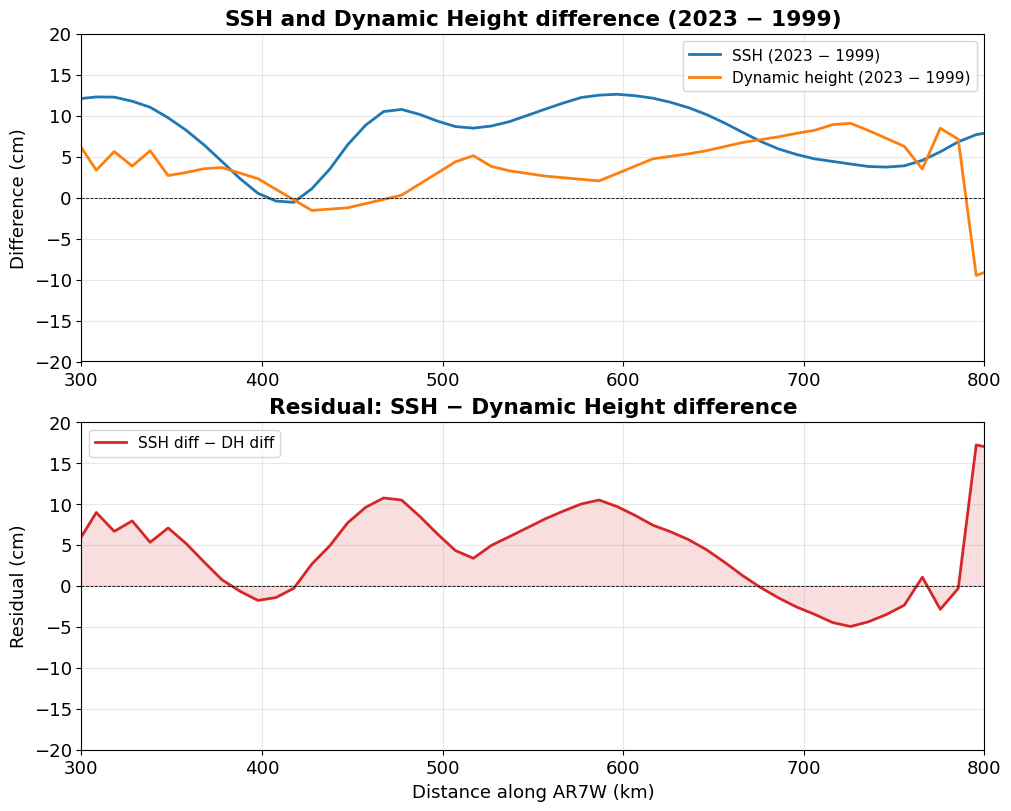

In [15]:
# ── Convert units for plotting (both to cm) ───────────────────────────────────
ssh_diff_cm = ssh_diff.values * 100
dh_diff_cm  = dh_diff.values * 100 
residual_cm = ssh_diff_cm - dh_diff_cm

dist = dh_diff.distance_km.values

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.rcParams["font.size"] = 13
fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

# --- Panel 1: SSH diff and DH diff ---
ax = axes[0]
ax.plot(dist, ssh_diff_cm, color="tab:blue",   linewidth=2, label="SSH (2023 − 1999)")
ax.plot(dist, dh_diff_cm,  color="tab:orange", linewidth=2, label="Dynamic height (2023 − 1999)")
ax.axhline(0, color="k", linewidth=0.6, linestyle="--")
ax.set_ylabel("Difference (cm)")
ax.set_title("SSH and Dynamic Height difference (2023 − 1999)", fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax.set_ylim(-20,20)
ax.set_xlim(300,800)

# SW / NE end markers
for a in axes:
    a.axvline(dist[0],  color="gray", linewidth=0.8, linestyle=":", alpha=0.7)
    a.axvline(dist[-1], color="gray", linewidth=0.8, linestyle=":", alpha=0.7)

# --- Panel 2: Residual (SSH - DH) ---
axes[1].plot(dist, residual_cm, color="tab:red", linewidth=2, label="SSH diff − DH diff")
axes[1].fill_between(dist, residual_cm, 0, alpha=0.15, color="tab:red")
axes[1].axhline(0, color="k", linewidth=0.6, linestyle="--")
axes[1].set_xlabel("Distance along AR7W (km)")
axes[1].set_ylabel("Residual (cm)")
axes[1].set_title("Residual: SSH − Dynamic Height difference", fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[1].set_ylim(-20,20)
axes[1].set_xlim(300,800)

plt.show()

# ── Cleanup ───────────────────────────────────────────────────────────────────
ds_dh.close()
ds_1999.close()
ds_2023.close()